# OrientationJ Vector Field (Python GST)

Faithful Python reproduction of **OrientationJ Vector Field** on the 16 images of
[../orientationj-test-images](../../orientationj-test-images): the orientation vectors (cos θ, sin θ), the
coherency and the energy are block-averaged on a grid of **16 × 16 pixels**
(cubic-spline gradient, σ = 1; vector scale 100 %, constant vector length — the
plugin defaults except the grid, which defaults to 10 in the dialog).

**Only the cells with more than 50 % of their area inside the mask** of
[../orientationj-test-images/masks](../../orientationj-test-images/masks) are kept (the mask fraction counts the
full grid × grid block, so partial border blocks are penalised).

For every image, `results/vectorfield/` receives `<name>-vectors.csv` in the exact
format of the OJ-Vector-Field results table:

| column | content |
|---|---|
| `X`, `Y` | center of the grid cell in pixels |
| `Slice` | always 0, kept for parity with the plugin table |
| `DX`, `DY` | block-averaged orientation vector (DX sign-flipped, like the plugin) |
| `Orientation` | vector angle in degrees, folded to [−90, +90] |
| `Coherency` | block-averaged coherency |
| `Energy` | block-averaged energy, normalized by the image maximum |

The overlays below draw one segment per grid cell, colored by its orientation with
the same hue wheel as the color survey. The notebook
ends with the summary page **`results/vectorfield/vectorfield-summary.md`**,
one figure per image.

In [1]:
import datetime
import glob
import os

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.collections import LineCollection
import tifffile

import orientationj as oj

SIGMA = 1.0     # structure-tensor Gaussian window (OrientationJ default)
EPSILON = 0.001
GRID = 16       # vector grid size in pixels
SCALE = 100.0   # vector length in % of the grid (plugin default)
TYPE = 0        # 0 = constant vector length (plugin default)
MIN_MASK = 0.5  # keep a cell when more than 50 % of its area is masked
INPUT = os.path.join('..', '..', 'orientationj-test-images')
MASKS = os.path.join(INPUT, 'masks')
OUTPUT = os.path.join('results', 'vectorfield')
os.makedirs(OUTPUT, exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white', 'font.size': 10, 'axes.titlesize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#cfcec6', 'grid.color': '#e8e8e4', 'grid.linewidth': 0.8,
    'text.color': '#3a3a37', 'axes.labelcolor': '#3a3a37',
    'xtick.color': '#6b6a63', 'ytick.color': '#6b6a63'})
ACCENT = '#4878a8'

In [2]:
paths = sorted(glob.glob(os.path.join(INPUT, 'images', '*.tif')))
images = {os.path.splitext(os.path.basename(p))[0]: oj.load(p) for p in paths}
for name, image in images.items():
    print(f'{name:42s} {image.shape}')
names = list(images.keys())
print(len(names), 'images')

masks = {name: tifffile.imread(os.path.join(MASKS, name + '.tif')) > 0
         for name in names}
for name in names:
    print(f'{name:42s} mask covers {100 * masks[name].mean():5.1f} % of the image')

cell_aemisegger                            (728, 728)
collagen                                   (512, 512)
dendrochronology                           (512, 512)
fibronectin_arafat_plos2025                (1024, 1024)
fibrous_tissues_fibero2024                 (2048, 2048)
fiji_directionality_montage                (1536, 1536)
nanofiber_fiji_diameterj                   (512, 512)
polymer_slice_quanfima2018                 (600, 600)
synthetic_chirp_1024                       (1024, 1024)
synthetic_filaments_512                    (512, 512)
synthetic_nematic_512                      (512, 512)
synthetic_noise_512                        (512, 512)
synthetic_rings_dither_512                 (512, 512)
synthetic_spiral_512                       (512, 512)
synthetic_wave_512                         (512, 512)
z_artificial_fibers                        (512, 683)
16 images
cell_aemisegger                            mask covers  25.8 % of the image
collagen                                  

In [3]:
tables = {}
for name, image in images.items():
    f = oj.analysis(image, sigma=SIGMA, epsilon=EPSILON)
    table = oj.vector_field(f, grid=GRID, mask=masks[name],
                            min_mask_fraction=MIN_MASK)
    table.to_csv(os.path.join(OUTPUT, name + '-vectors.csv'), index=False)
    tables[name] = table
    print(f'{name:42s} {len(table):6d} vectors   mean coherency '
          f'{table.Coherency.mean():.3f}')

cell_aemisegger                               486 vectors   mean coherency 0.659
collagen                                      456 vectors   mean coherency 0.606


dendrochronology                              534 vectors   mean coherency 0.922


fibronectin_arafat_plos2025                  2365 vectors   mean coherency 0.276


fibrous_tissues_fibero2024                    156 vectors   mean coherency 0.565


fiji_directionality_montage                  7852 vectors   mean coherency 0.649
nanofiber_fiji_diameterj                      352 vectors   mean coherency 0.403


polymer_slice_quanfima2018                     10 vectors   mean coherency 0.001


synthetic_chirp_1024                         2654 vectors   mean coherency 0.965
synthetic_filaments_512                       532 vectors   mean coherency 0.608


synthetic_nematic_512                        1022 vectors   mean coherency 0.570
synthetic_noise_512                          1024 vectors   mean coherency 0.289


synthetic_rings_dither_512                    223 vectors   mean coherency 0.765
synthetic_spiral_512                         1024 vectors   mean coherency 0.896


synthetic_wave_512                           1024 vectors   mean coherency 0.925
z_artificial_fibers                           911 vectors   mean coherency 0.502


In [4]:
def draw_vector_field(ax, image, table, grid, linewidth=1.1):
    """Grayscale image with one segment per grid cell, hue = orientation."""
    ax.imshow(image, cmap='gray')
    x1, y1, x2, y2 = oj.vector_segments(table, grid=grid, scale=SCALE,
                                        vector_type=TYPE)
    segments = np.stack([np.column_stack([x1, y1]),
                         np.column_stack([x2, y2])], axis=1)
    hue = (table['Orientation'].to_numpy() + 90.0) / 180.0
    ax.add_collection(LineCollection(segments, colors=colormaps['hsv'](hue),
                                     linewidths=linewidth))
    ax.axis('off')

## Vector fields (inside the mask)

One segment per 16 × 16 cell with more than 50 % of its area masked, constant
length (type 0), colored by orientation (−90° red → cyan → +90° red).

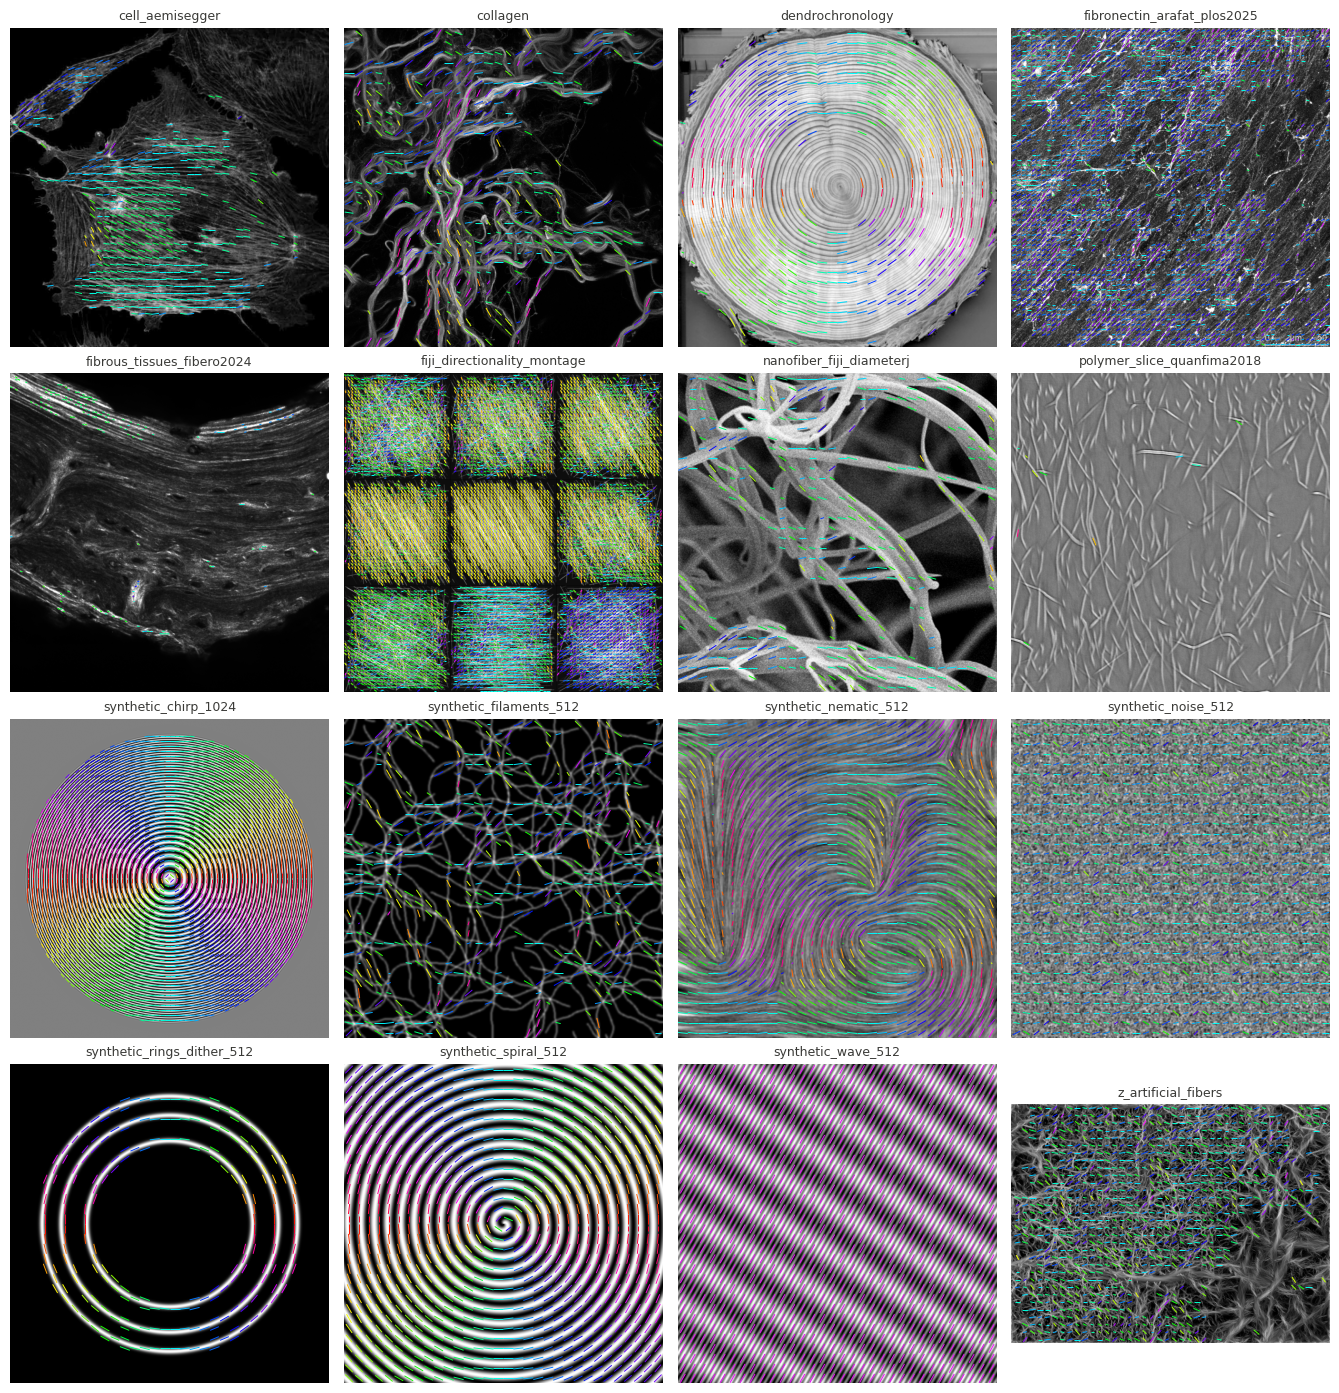

In [5]:
rows = -(-len(names) // 4)
fig, axes = plt.subplots(rows, 4, figsize=(13.5, 3.5 * rows))
for ax in axes.flat:
    ax.axis('off')
for ax, name in zip(axes.flat, names):
    draw_vector_field(ax, images[name], tables[name], GRID, linewidth=0.7)
    ax.set_title(name, fontsize=9)
fig.tight_layout()
plt.show()

## Summary page

One full-size vector field per image. Written to
`results/vectorfield/vectorfield-summary.md`
(figures in `results/vectorfield/figures/`).

In [6]:
FIGURES = os.path.join(OUTPUT, 'figures')
os.makedirs(FIGURES, exist_ok=True)

lines = [
    '# OrientationJ Vector Field — Python GST',
    '',
    '*Generated on ' + datetime.date.today().isoformat()
        + ' by [vector_field.ipynb](../../vector_field.ipynb).*',
    '',
    '- Block-averaged orientation vector field, grid ' + str(GRID) + ' × ' + str(GRID)
        + ' pixels',
    '- Gradient: cubic spline (plugin default), structure-tensor window sigma = '
        + str(SIGMA),
    '- Mask: cells with more than ' + str(int(MIN_MASK * 100))
        + ' % masked area (orientationj-test-images/masks)',
    '- Vectors: scale ' + str(int(SCALE)) + ' %, constant length (type ' + str(TYPE)
        + '), hue = orientation',
    '- Per image: `<name>-vectors.csv` in the OJ-Vector-Field table format',
    '']

for name in names:
    image = images[name]
    table = tables[name]

    fig, ax = plt.subplots(figsize=(9.5, 9.5 * image.shape[0] / image.shape[1]))
    draw_vector_field(ax, image, table, GRID)
    fig.savefig(os.path.join(FIGURES, name + '.png'), dpi=130, bbox_inches='tight')
    plt.close(fig)

    lines += ['## ' + name,
              '',
              str(len(table)) + ' vectors — mean coherency '
                  + format(table.Coherency.mean(), '.3f'),
              '', '![' + name + '](figures/' + name + '.png)', '']

page_path = os.path.join(OUTPUT, 'vectorfield-summary.md')
open(page_path, 'w').write('\n'.join(lines))
print('written', page_path)

written results/vectorfield/vectorfield-summary.md
